In [18]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

# Pour que le notebook trouve les fichiers .py locaux
sys.path.append(os.getcwd())

from laplace_models import NeuralNetworkRegression
from variational_models import VariationalNeuralRegression

In [19]:
# Dataset 1D avec gap dans (1.5, 3)

n_total = 200
x_full = np.linspace(-4.0, 10.0, n_total)

def latent_function(x):
    return np.sin(x) + 0.3 * np.cos(2.0 * x)

y_full = latent_function(x_full) + 0.15 * np.random.randn(n_total)

gap_mask = (x_full < 1.5) | (x_full > 3.0)

x_train = x_full[gap_mask][:, None]
y_train = y_full[gap_mask]

x_test = np.linspace(-4.5, 10.5, 400)[:, None]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)

x_train shape: (179, 1)
y_train shape: (179,)
x_test shape : (400, 1)


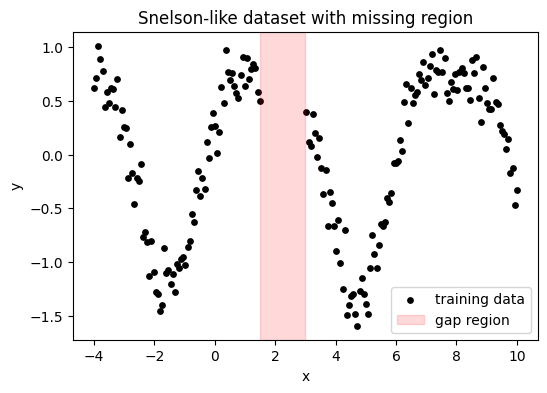

In [20]:
plt.figure(figsize=(6,4))

plt.scatter(x_train, y_train, color="black", s=15, label="training data")

plt.axvspan(1.5, 3.0, color="red", alpha=0.15, label="gap region")

plt.title("Snelson-like dataset with missing region")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.show()

In [21]:
delta = 1.0
sigma_noise = 0.15

laplace_model = NeuralNetworkRegression(
    X=x_train.astype(np.float64),
    y=y_train.astype(np.float64),
    delta=delta,
    sigma_noise=sigma_noise,
    compute_posterior=True,
    n_epochs=3000,
    activation='sigmoid',
    step_size=1e-2,
    hidden_size=32,
    n_layers=2,
    n_samples_pred=500,
    diagonal=True
)

print("Nombre de paramètres :", laplace_model.d)
print("Dernière loss        :", laplace_model.losses[-1])

500 97.9346608625911
1000 -45.707839754682155
1500 -47.47562515978794
2000 -50.17796422849894
2500 -50.70738848383235
3000 -52.53758589398556
Nombre de paramètres : 97
Dernière loss        : 182.8641671061758


In [22]:
# Prédiction MAP
y_map = laplace_model.predictive_map(x_test.astype(np.float64)).reshape(-1)

# Prédiction postérieure par Monte Carlo sur les poids
mu_laplace, var_laplace = laplace_model.posterior_predictive_f(
    x_test.astype(np.float64),
    hessian_approx='J',
    compute_cov=True,
    diag_only=True
)

mu_laplace = mu_laplace.reshape(-1)
std_laplace = np.sqrt(var_laplace.reshape(-1))

print("MAP shape         :", y_map.shape)
print("Laplace mean shape:", mu_laplace.shape)
print("Laplace std shape :", std_laplace.shape)

MAP shape         : (400,)
Laplace mean shape: (400,)
Laplace std shape : (400,)


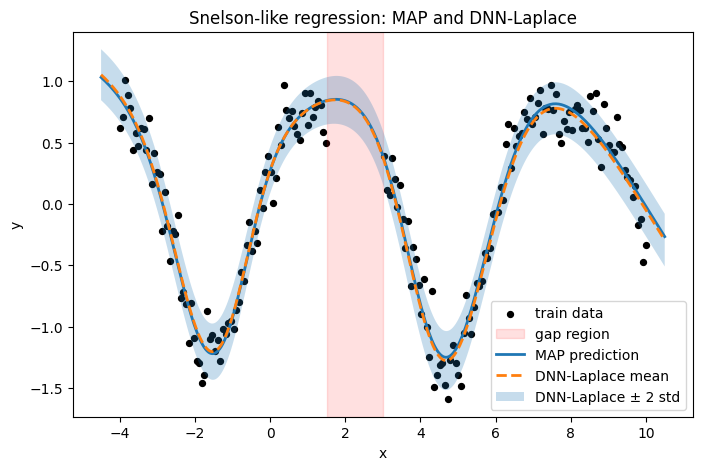

In [23]:
plt.figure(figsize=(8, 5))

# données
plt.scatter(x_train[:, 0], y_train, color='black', s=18, label='train data')

# zone sans données
plt.axvspan(1.5, 3.0, color='red', alpha=0.12, label='gap region')

# MAP
plt.plot(x_test[:, 0], y_map, linewidth=2, label='MAP prediction')

# Laplace mean
plt.plot(x_test[:, 0], mu_laplace, linewidth=2, linestyle='--', label='DNN-Laplace mean')

# confidence band
plt.fill_between(
    x_test[:, 0],
    mu_laplace - 2.0 * std_laplace,
    mu_laplace + 2.0 * std_laplace,
    alpha=0.25,
    label='DNN-Laplace ± 2 std'
)

plt.title("Snelson-like regression: MAP and DNN-Laplace")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [24]:
# Posterior Laplace-GGN sur les poids
theta_star, S_laplace, P_laplace = laplace_model.q_laplace('J')

# Jacobiens J(x_*) pour tous les points de test
J_test = []

laplace_model.model.eval()
for x in x_test:
    xi = torch.from_numpy(x[None, :]).double()  # shape (1, 1)
    laplace_model.model.zero_grad()
    out = laplace_model.model(xi).squeeze()
    out.backward()
    J_test.append(laplace_model.model.gradient.copy())

J_test = np.stack(J_test)   # shape (n_test, d)

# Moyenne prédictive DNN2GP-Laplace sur y_*
mu_dnn2gp_laplace = laplace_model.predictive_map(x_test.astype(np.float64)).reshape(-1)

# Variance prédictive diag[J S J^T] + sigma_noise^2
var_f_dnn2gp_laplace = np.einsum('nd,dd,nd->n', J_test, S_laplace, J_test)
var_y_dnn2gp_laplace = var_f_dnn2gp_laplace + laplace_model.sigma_noise**2
std_dnn2gp_laplace = np.sqrt(var_y_dnn2gp_laplace)

print("J_test shape                 :", J_test.shape)
print("mu_dnn2gp_laplace shape      :", mu_dnn2gp_laplace.shape)
print("std_dnn2gp_laplace shape     :", std_dnn2gp_laplace.shape)

J_test shape                 : (400, 97)
mu_dnn2gp_laplace shape      : (400,)
std_dnn2gp_laplace shape     : (400,)


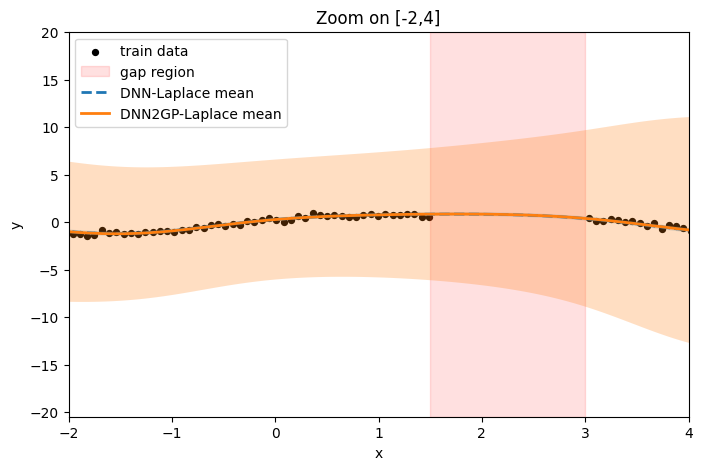

In [25]:
plt.figure(figsize=(8, 5))

# données
plt.scatter(x_train[:, 0], y_train, color='black', s=18, label='train data')
plt.axvspan(1.5, 3.0, color='red', alpha=0.12, label='gap region')

# DNN-Laplace
plt.plot(x_test[:, 0], mu_laplace, linewidth=2, linestyle='--', label='DNN-Laplace mean')
plt.fill_between(
    x_test[:, 0],
    mu_laplace - 2.0 * std_laplace,
    mu_laplace + 2.0 * std_laplace,
    alpha=0.20
)

# DNN2GP-Laplace
plt.plot(x_test[:, 0], mu_dnn2gp_laplace, linewidth=2, label='DNN2GP-Laplace mean')
plt.fill_between(
    x_test[:, 0],
    mu_dnn2gp_laplace - 2.0 * std_dnn2gp_laplace,
    mu_dnn2gp_laplace + 2.0 * std_dnn2gp_laplace,
    alpha=0.25
)

# ZOOM
plt.xlim(-2, 4)

plt.title("Zoom on [-2,4]")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()